In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
#Load dataset

housing=fetch_california_housing()

data=pd.DataFrame(housing.data,
columns= housing.feature_names)
data["Price"] =housing.target

In [16]:
x = data[['AveRooms']].values
y = data['Price'].values

In [20]:
#split data

x_train , x_test , y_train , y_test = train_test_split(
    x , y ,
    test_size = 0.2,
    random_state = 42
)
                                                        

In [24]:
#feature scaling

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [75]:
w =0 
b =0
learning_rate =0.01
epochs =1000
cost_history=[]

n= len(x_train_scaled)

for i in range(epochs) :
      y_pred =w*x_train_scaled.flatten() + b
      dw =(1/n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
      db =(1/n) * np.sum(y_pred-y_train)
      w = w - learning_rate *dw
      b = b - learning_rate*db

      if i % 100==0:
          cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
          cost_history.append(cost)
          print(f"Epoch {i}, cost = {cost : .4f}")

y_pred_gd = w * x_test_scaled.flatten() + b     

Epoch 0, cost =  2.8149
Epoch 100, cost =  0.9414
Epoch 200, cost =  0.6904
Epoch 300, cost =  0.6568
Epoch 400, cost =  0.6523
Epoch 500, cost =  0.6517
Epoch 600, cost =  0.6516
Epoch 700, cost =  0.6516
Epoch 800, cost =  0.6516
Epoch 900, cost =  0.6516


In [77]:
print("Gradient descent")
print("----------------")
print("Weight:",w)
print("bias :" ,b)
print("MSE : ",mean_squared_error(y_test,y_pred_gd))
print("R2 Score: ",r2_score(y_test,y_pred_gd))

Gradient descent
----------------
Weight: 0.18323090648660517
bias : 2.0718574888450205
MSE :  1.292327655590046
R2 Score:  0.013798228607320828


In [78]:
#Normal Equation

x_train_ne = np.c_[np.ones((len(x_train),1)), x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)), x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne. T @ y_train

y_pred_ne = x_test_ne @theta

In [80]:
print("\nNormal Equation")
print("------------------")
print("Intercept:" , theta[0])
print("Slope:" , theta[1])
print("MSE:", mean_squared_error(y_test,y_pred_ne))
print("R2 Score :", r2_score(y_test,y_pred_ne))


Normal Equation
------------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score : 0.013795337532284901


In [81]:
#sort values for smooth regressin line

sort_axis = np.argsort(x_test.flatten())
x_sorted = x_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

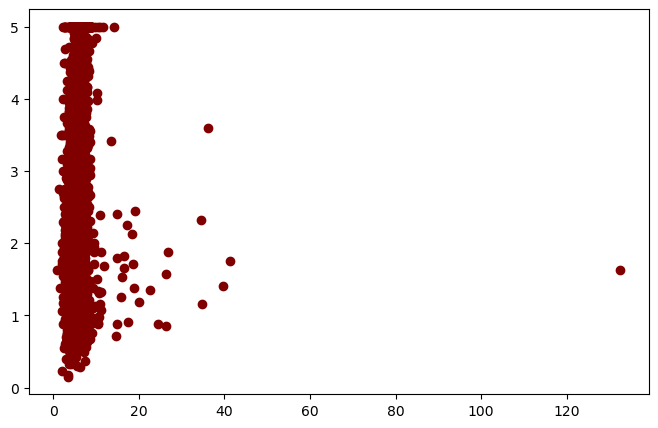

In [83]:
#regression line visualization

# sort x values for a smooth line

index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))

#scatter plot

plt.scatter(x_test, y_test, color='maroon', label='actual Data')

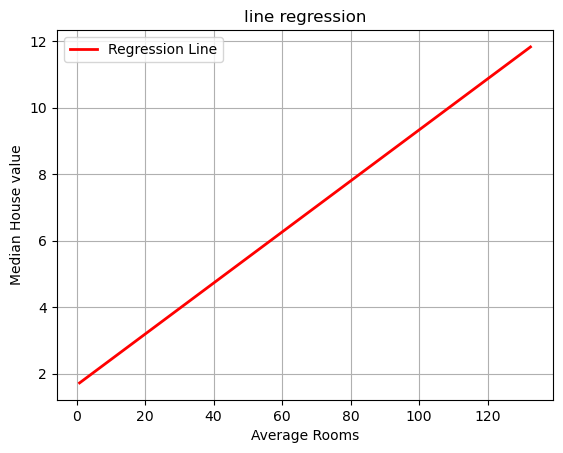

In [84]:
#regression line

plt.plot (
    x_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("line regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House value")
plt.legend()
plt.grid(True)
plt.show()

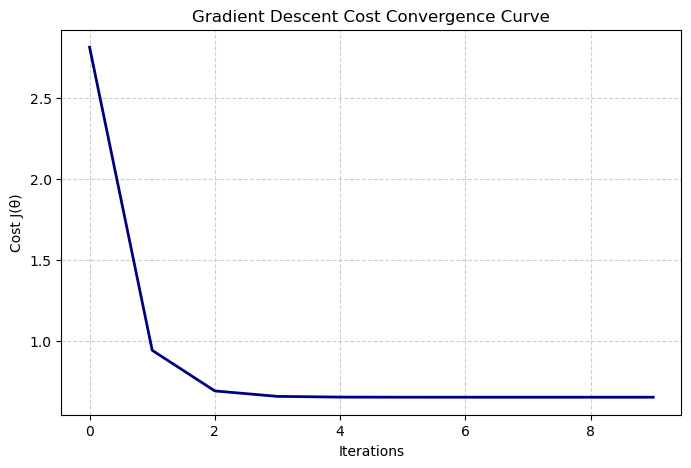

In [87]:
#cost convergence curve

plt.figure(figsize=(8,5))

plt.plot(cost_history, color='navy', linewidth=2)

plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(θ)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()